In [1]:
import pandas as pd
import numpy as np
import shutil
import re
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

In [2]:
from pathlib import Path
CSV_PATH = Path("/kaggle/input/pm25vision/train/metadata.csv")
IMG_DIR  = Path("/kaggle/input/pm25vision/train/images")
OUT_DIR  = Path("/kaggle/working/dataset")
OUT_DIR.mkdir(parents=True, exist_ok=True)

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return "Unknown"

def bin_to_label(bin_val) -> str:
    """
    Accepts '0–50', '0-50', '0 — 50', etc.
    Extracts the LOWER numeric bound and maps to label.
    """
    s = str(bin_val).strip()
    
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
 
    s = re.sub(r"\s*-\s*", "-", s)
  
    m = re.search(r"(\d+)", s)
    if not m:
        return "Unknown"
    lo = int(m.group(1))
    return aqi_to_label(lo)

df = pd.read_csv(CSV_PATH)
assert "pm25_bin" in df.columns, f"Expected 'pm25_bin' column but found {df.columns}"


fname_col = "filename" if "filename" in df.columns else ("file" if "file" in df.columns else None)
if fname_col is None:
    raise ValueError(f"No image filename column found. Columns: {list(df.columns)}")

df["fname"] = df[fname_col].astype(str)


df["level"] = df["pm25_bin"].apply(bin_to_label)


print("Class counts:")
print(df["level"].value_counts(dropna=False))


for _, _, label in AQI_BINS:
    (OUT_DIR / label).mkdir(parents=True, exist_ok=True)
(OUT_DIR / "Unknown").mkdir(parents=True, exist_ok=True)

missing = 0
copied  = 0

for _, row in df.iterrows():
    src = IMG_DIR / row["fname"]
    if not src.exists():
        missing += 1
        continue

    label = row["level"] if row["level"] in {b[2] for b in AQI_BINS} else "Unknown"
    dst = OUT_DIR / label / src.name
    shutil.copy2(src, dst)
    copied += 1

print(f"✅ Done! Copied: {copied} | Missing files skipped: {missing}")
print(f"Output root: {OUT_DIR}")


Class counts:
level
Good                   1780
Moderate               1780
Unhealthy_Sensitive    1780
Unhealthy              1780
Very_Unhealthy          822
Hazardous               356
Name: count, dtype: int64
✅ Done! Copied: 8298 | Missing files skipped: 0
Output root: /kaggle/working/dataset


In [3]:
from pathlib import Path
TEST_CSV_PATH = Path("/kaggle/input/pm25vision/test/metadata.csv")
TEST_IMG_DIR  = Path("/kaggle/input/pm25vision/test/images")

AQI_BINS = [
    (0, 50, "Good"),
    (51, 100, "Moderate"),
    (101, 150, "Unhealthy_Sensitive"),
    (151, 200, "Unhealthy"),
    (201, 300, "Very_Unhealthy"),
    (301, 10000, "Hazardous"),
]

def aqi_to_label(aqi: int) -> str:
    for lo, hi, label in AQI_BINS:
        if lo <= aqi <= hi:
            return label
    return "Unknown"

def bin_to_label(bin_val) -> str:
    s = str(bin_val).strip()
    s = s.replace("–", "-").replace("—", "-").replace("−", "-")
    s = re.sub(r"\s*-\s*", "-", s)
    m = re.search(r"(\d+)", s)
    if not m:
        return "Unknown"
    lo = int(m.group(1))
    return aqi_to_label(lo)

df_t = pd.read_csv(TEST_CSV_PATH)
assert "pm25_bin" in df_t.columns, f"Expected 'pm25_bin' in TEST CSV, got: {df_t.columns}"

fname_col_t = "filename" if "filename" in df_t.columns else ("file" if "file" in df_t.columns else None)
if fname_col_t is None:
    raise ValueError(f"No image filename column in TEST CSV. Columns: {list(df_t.columns)}")

df_t["fname"] = df_t[fname_col_t].astype(str)
df_t["level"] = df_t["pm25_bin"].apply(bin_to_label)


missing, copied, skipped_same, renamed_dupe = 0, 0, 0, 0
valid_labels = {b[2] for b in AQI_BINS}

for _, r in df_t.iterrows():
    src = TEST_IMG_DIR / r["fname"]
    if not src.exists():
        missing += 1
        continue

    label = r["level"] if r["level"] in valid_labels else "Unknown"
    dest_dir = OUT_DIR / label
    dest_dir.mkdir(parents=True, exist_ok=True)

    dst = dest_dir / src.name
    if dst.exists():
    
        if os.path.getsize(dst) == os.path.getsize(src):
            skipped_same += 1
            continue
      
        dst = dest_dir / f"test__{src.name}"
        renamed_dupe += 1

    shutil.copy2(src, dst)
    copied += 1

print("✅ TEST merge complete.")
print(f"Copied: {copied} | Missing files: {missing} | Skipped exact-duplicates: {skipped_same} | Renamed (name clash): {renamed_dupe}")
print(f"Merged into: {OUT_DIR}")


✅ TEST merge complete.
Copied: 2905 | Missing files: 0 | Skipped exact-duplicates: 16 | Renamed (name clash): 0
Merged into: /kaggle/working/dataset


In [4]:
from pathlib import Path

OUT_DIR = Path("/kaggle/working/dataset")

class_counts = {}
for sub in OUT_DIR.iterdir():
    if sub.is_dir():
        class_counts[sub.name] = len(list(sub.glob("*")))
        
print(" Image count per class:")
for k, v in sorted(class_counts.items()):
    print(f"{k:20s}: {v}")
    
print("\nTotal images:", sum(class_counts.values()))


 Image count per class:
Good                : 2408
Hazardous           : 481
Moderate            : 2407
Unhealthy           : 2407
Unhealthy_Sensitive : 2393
Unknown             : 0
Very_Unhealthy      : 1007

Total images: 11103


Setup & indexing

In [5]:
from pathlib import Path
from PIL import Image

BASE_DIR = Path("/kaggle/working/dataset")  
assert BASE_DIR.exists(), BASE_DIR

rows = []
for label_dir in sorted([p for p in BASE_DIR.iterdir() if p.is_dir()]):
    label = label_dir.name
    for p in label_dir.glob("*"):
        if p.suffix.lower() not in {".jpg", ".jpeg", ".png"}:
            continue
        rows.append({"path": str(p), "label": label})

df = pd.DataFrame(rows)
print("Total images indexed:", len(df))
print("Class balance:\n", df["label"].value_counts())

def load_rgb(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return np.array(im)

df.head(20)


Total images indexed: 11103
Class balance:
 label
Good                   2408
Moderate               2407
Unhealthy              2407
Unhealthy_Sensitive    2393
Very_Unhealthy         1007
Hazardous               481
Name: count, dtype: int64


,path,label
0,/kaggle/working/dataset/Good/1429170910754806.jpg,Good
1,/kaggle/working/dataset/Good/466783541076069.jpg,Good
2,/kaggle/working/dataset/Good/137573882028202.jpg,Good
3,/kaggle/working/dataset/Good/505268673951240.jpg,Good
4,/kaggle/working/dataset/Good/462393535027278.jpg,Good
5,/kaggle/working/dataset/Good/158175856176649.jpg,Good
6,/kaggle/working/dataset/Good/499282664751996.jpg,Good
7,/kaggle/working/dataset/Good/153084533494552.jpg,Good
8,/kaggle/working/dataset/Good/178329837408715.jpg,Good
9,/kaggle/working/dataset/Good/1470829433664798.jpg,Good


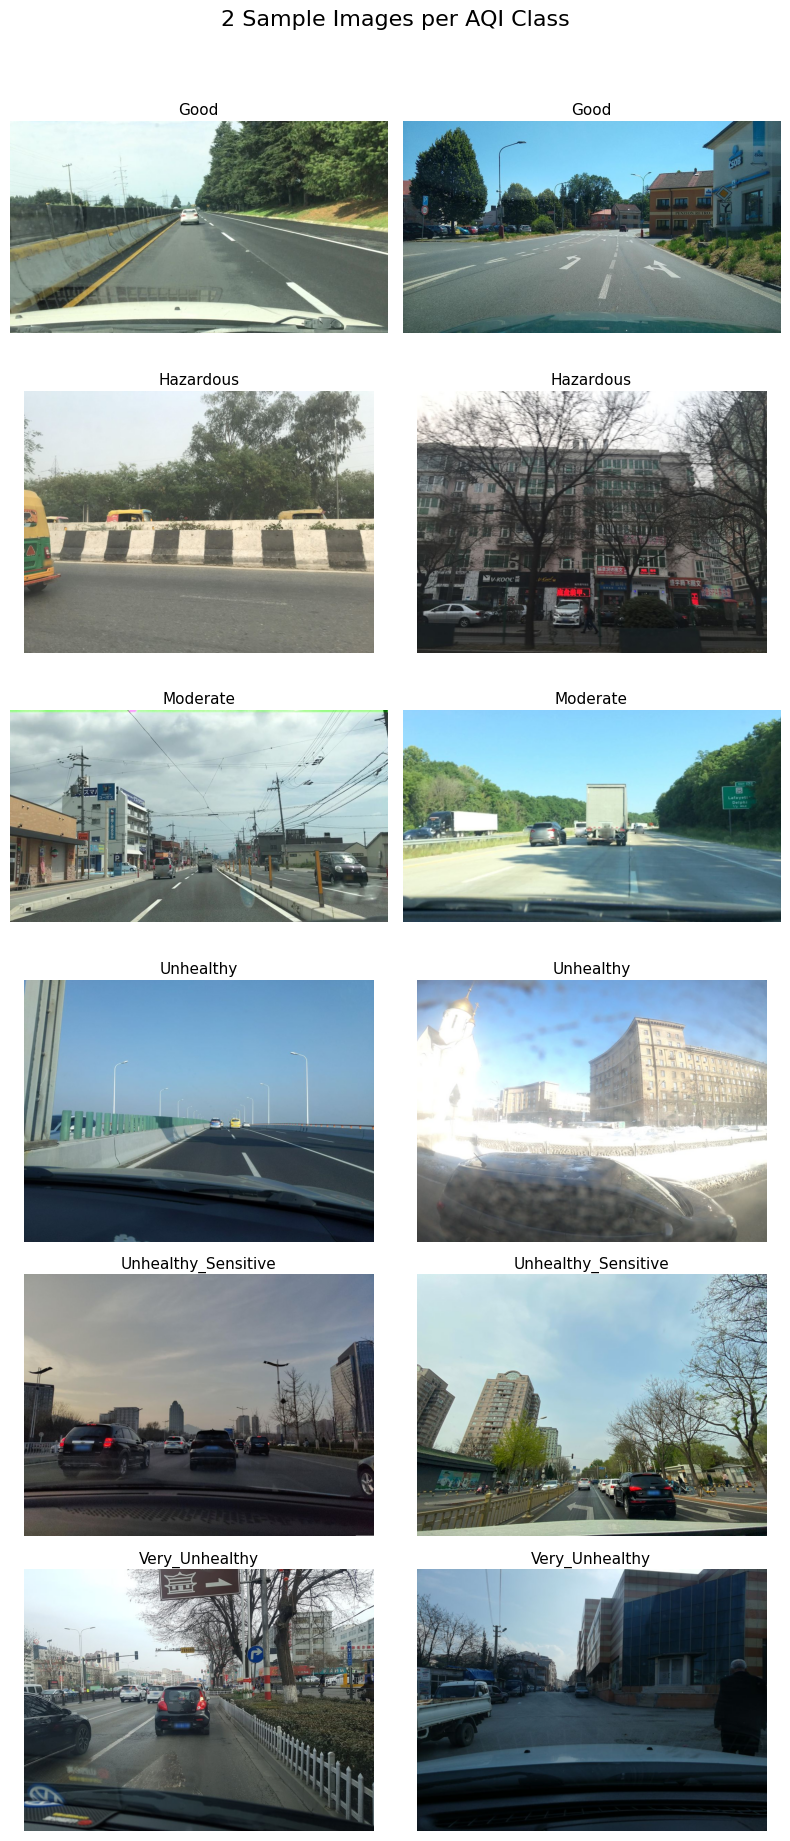

In [7]:
from PIL import Image

classes = sorted(df["label"].unique())

N_PER_CLASS = 2

plt.figure(figsize=(N_PER_CLASS * 4, len(classes) * 3))

for i, lbl in enumerate(classes):
    subset = df[df["label"] == lbl]["path"].tolist()
    sample_paths = random.sample(subset, min(N_PER_CLASS, len(subset)))
    
    for j, path in enumerate(sample_paths):
        idx = i * N_PER_CLASS + j + 1
        plt.subplot(len(classes), N_PER_CLASS, idx)
        
        img = Image.open(path)
        plt.imshow(img)
        plt.axis("off")
        
        plt.title(lbl, fontsize=11, pad=4)

plt.suptitle("2 Sample Images per AQI Class", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [8]:
import cv2
def rgb_hsv_stats(img):
    arr = img.astype(np.float32) / 255.0
    r_mean, g_mean, b_mean = arr[...,0].mean(), arr[...,1].mean(), arr[...,2].mean()
    r_std,  g_std,  b_std  = arr[...,0].std(),  arr[...,1].std(),  arr[...,2].std()
    hsv = cv2.cvtColor((arr*255).astype(np.uint8), cv2.COLOR_RGB2HSV)
    H = hsv[...,0].astype(np.float32)/179.0
    S = hsv[...,1].astype(np.float32)/255.0
    V = hsv[...,2].astype(np.float32)/255.0
    h_mean, s_mean, v_mean = H.mean(), S.mean(), V.mean()
    h_std,  s_std,  v_std  = H.std(),  S.std(),  V.std()
    gray = cv2.cvtColor((arr*255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(np.float32)/255.0
    brightness = gray.mean()
    contrast   = gray.std()
    sat_low_pct  = float((S < 0.05).mean())
    sat_high_pct = float((S > 0.95).mean())
    return {
        "r_mean": r_mean, "g_mean": g_mean, "b_mean": b_mean,
        "r_std": r_std,   "g_std": g_std,   "b_std": b_std,
        "h_mean": h_mean, "s_mean": s_mean, "v_mean": v_mean,
        "h_std": h_std,   "s_std": s_std,   "v_std": v_std,
        "brightness": brightness, "contrast": contrast,
        "sat_low_pct": sat_low_pct, "sat_high_pct": sat_high_pct
    }

def laplacian_variance(gray_u8):
    lap = cv2.Laplacian(gray_u8, cv2.CV_32F)
    return float(lap.var())

def noise_proxy(gray_u8):
    med = cv2.medianBlur(gray_u8, 3)
    return float(np.mean(np.abs(gray_u8.astype(np.float32) - med.astype(np.float32))))

stats = []
for i, row in df.iterrows():
    img = load_rgb(row["path"])
    h, w = img.shape[:2]
    aspect = w / h
    s = rgb_hsv_stats(img)
    gray_u8 = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    s["lap_var"] = laplacian_variance(gray_u8)
    s["noise_proxy"] = noise_proxy(gray_u8)
    s["width"], s["height"], s["aspect"] = int(w), int(h), float(aspect)
    stats.append(s)

stats_df = pd.DataFrame(stats)
df = pd.concat([df, stats_df], axis=1)
print("Stats computed. Columns now:", df.columns.tolist())

df.to_parquet("/kaggle/working/eda_stats.parquet", index=False)
df.head()


Stats computed. Columns now: ['path', 'label', 'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std', 'h_mean', 's_mean', 'v_mean', 'h_std', 's_std', 'v_std', 'brightness', 'contrast', 'sat_low_pct', 'sat_high_pct', 'lap_var', 'noise_proxy', 'width', 'height', 'aspect']


,path,label,r_mean,g_mean,b_mean,r_std,g_std,b_std,h_mean,s_mean,...,v_std,brightness,contrast,sat_low_pct,sat_high_pct,lap_var,noise_proxy,width,height,aspect
0,/kaggle/working/dataset/Good/1429170910754806.jpg,Good,0.362323,0.511086,0.608473,0.187960,0.196732,0.258359,0.478658,0.406442,...,0.253881,0.477636,0.183948,0.066638,0.005044,1109.100708,3.540633,1024,768,1.333333
1,/kaggle/working/dataset/Good/466783541076069.jpg,Good,0.461107,0.477200,0.484246,0.282937,0.298807,0.308264,0.413738,0.096957,...,0.303493,0.473221,0.294714,0.460783,0.008679,1570.054077,3.051804,1024,576,1.777778
2,/kaggle/working/dataset/Good/137573882028202.jpg,Good,0.338485,0.398275,0.421027,0.219186,0.234060,0.259811,0.479930,0.249007,...,0.256021,0.382984,0.231017,0.044545,0.001065,861.501892,2.835770,1024,576,1.777778
3,/kaggle/working/dataset/Good/505268673951240.jpg,Good,0.439648,0.580448,0.559864,0.204639,0.238523,0.245591,0.460414,0.294706,...,0.247369,0.535950,0.225508,0.005783,0.000000,96.055618,0.597529,1024,576,1.777778
4,/kaggle/working/dataset/Good/462393535027278.jpg,Good,0.384267,0.486011,0.572738,0.181698,0.217770,0.276670,0.546803,0.319749,...,0.269726,0.465420,0.210588,0.031686,0.000102,254.496078,1.314295,1024,768,1.333333


RGB & HSV histograms , brightness/contrast spread; saturation clipping;(per-class)

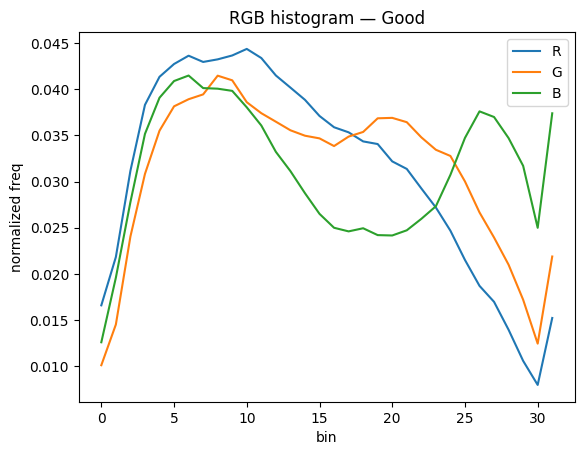

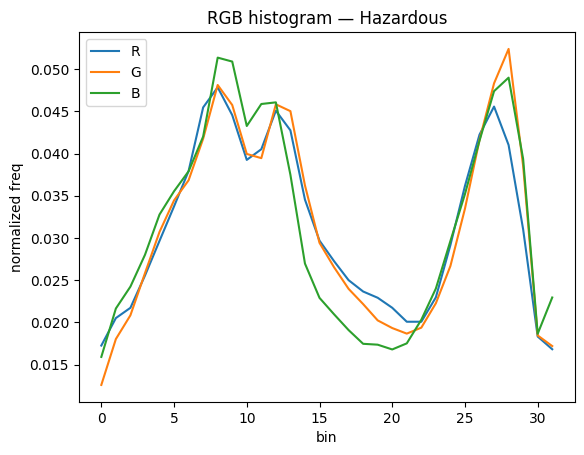

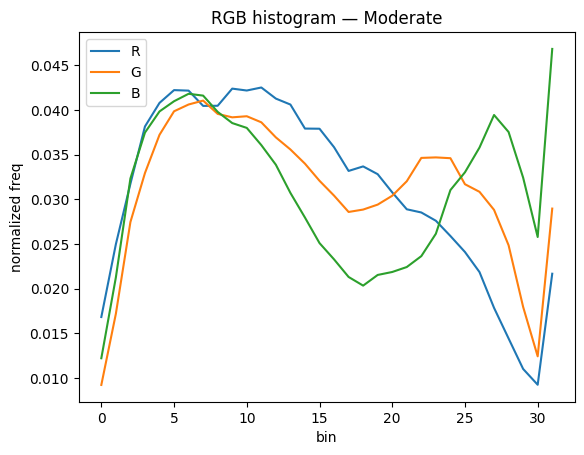

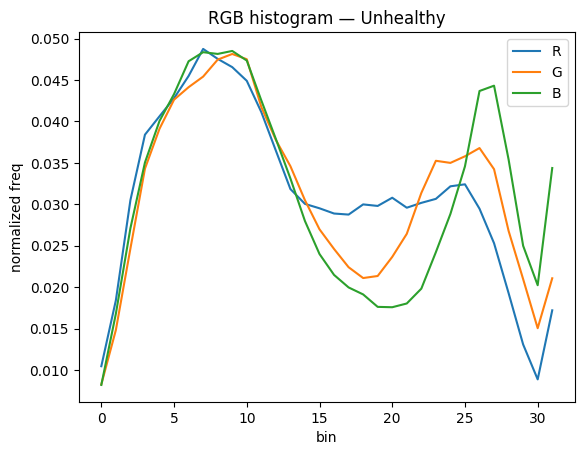

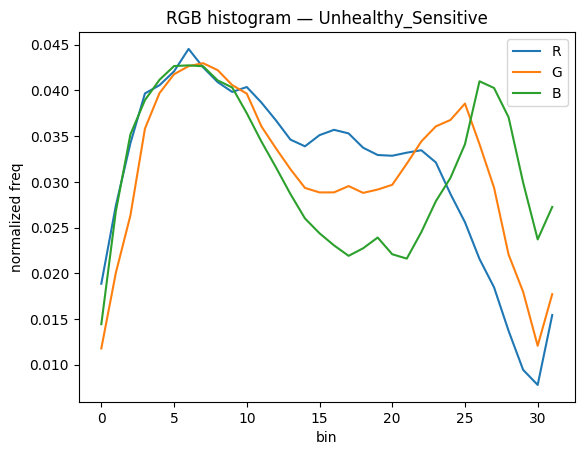

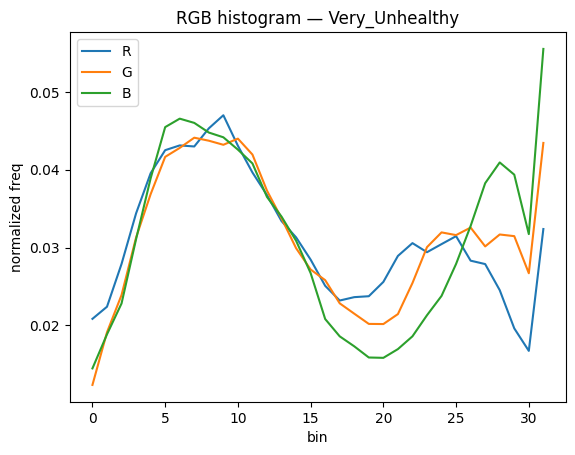

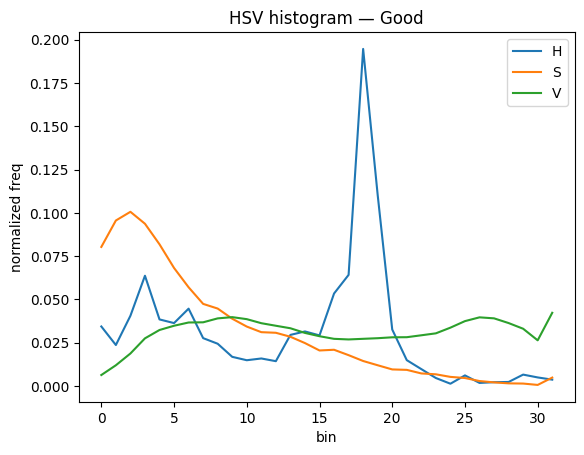

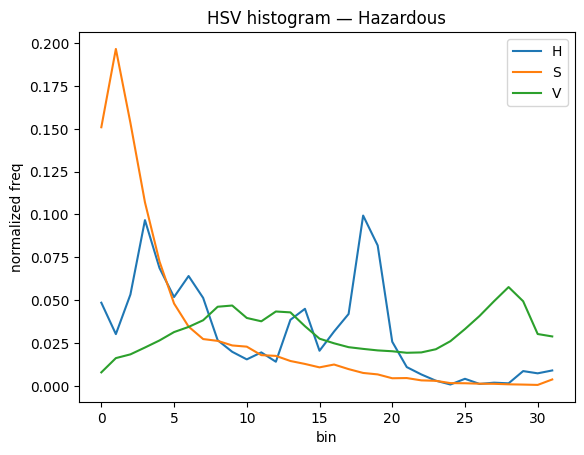

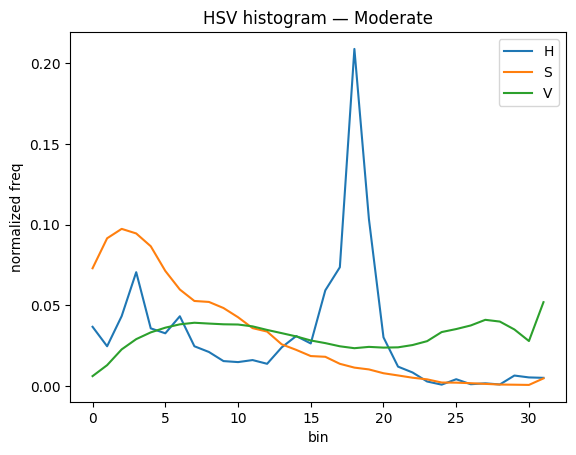

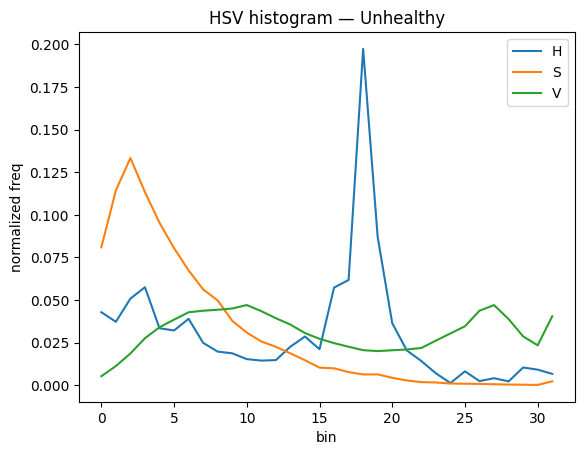

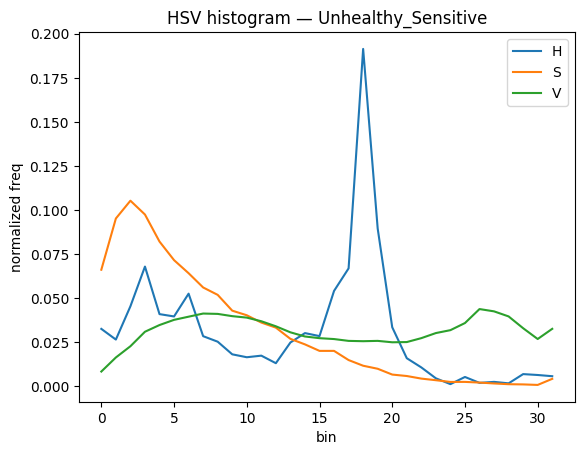

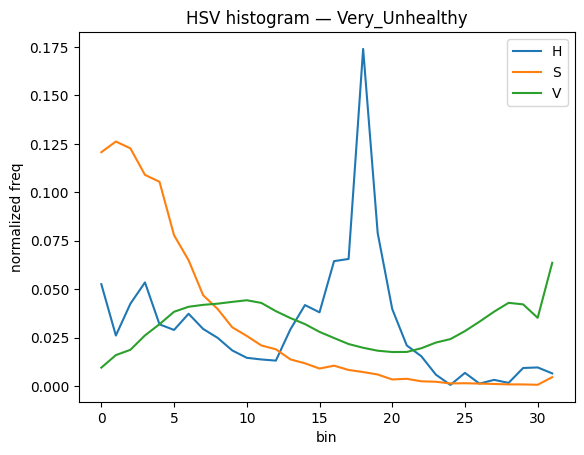

In [9]:
import matplotlib.pyplot as plt
from collections import defaultdict

MAX_PER_CLASS = 300
BINS = 32

def accumulate_hists(paths):
    rgb_h = np.zeros((3, BINS), dtype=np.float64)
    hsv_h = np.zeros((3, BINS), dtype=np.float64)
    for p in paths:
        arr = load_rgb(p)
        for c in range(3):
            hist, _ = np.histogram(arr[...,c], bins=BINS, range=(0,255))
            rgb_h[c] += hist
        hsv = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
        h_hist,_ = np.histogram(hsv[...,0], bins=BINS, range=(0,179))
        s_hist,_ = np.histogram(hsv[...,1], bins=BINS, range=(0,255))
        v_hist,_ = np.histogram(hsv[...,2], bins=BINS, range=(0,255))
        hsv_h[0]+=h_hist; hsv_h[1]+=s_hist; hsv_h[2]+=v_hist
    rgb_h = rgb_h / np.maximum(rgb_h.sum(axis=1, keepdims=True), 1)
    hsv_h = hsv_h / np.maximum(hsv_h.sum(axis=1, keepdims=True), 1)
    return rgb_h, hsv_h

per_class_paths = defaultdict(list)
for _, r in df.iterrows():
    per_class_paths[r["label"]].append(r["path"])

class_rgb_h, class_hsv_h = {}, {}
for label, paths in per_class_paths.items():
    paths = paths[:MAX_PER_CLASS]
    r, h = accumulate_hists(paths)
    class_rgb_h[label] = r
    class_hsv_h[label] = h

for label in sorted(class_rgb_h.keys()):
    r = class_rgb_h[label]
    plt.figure()
    plt.title(f"RGB histogram — {label}")
    x = np.arange(BINS)
    plt.plot(x, r[0], label="R")
    plt.plot(x, r[1], label="G")
    plt.plot(x, r[2], label="B")
    plt.legend()
    plt.xlabel("bin"); plt.ylabel("normalized freq")
    plt.show()

for label in sorted(class_hsv_h.keys()):
    h = class_hsv_h[label]
    plt.figure()
    plt.title(f"HSV histogram — {label}")
    x = np.arange(BINS)
    plt.plot(x, h[0], label="H")
    plt.plot(x, h[1], label="S")
    plt.plot(x, h[2], label="V")
    plt.legend()
    plt.xlabel("bin"); plt.ylabel("normalized freq")
    plt.show()


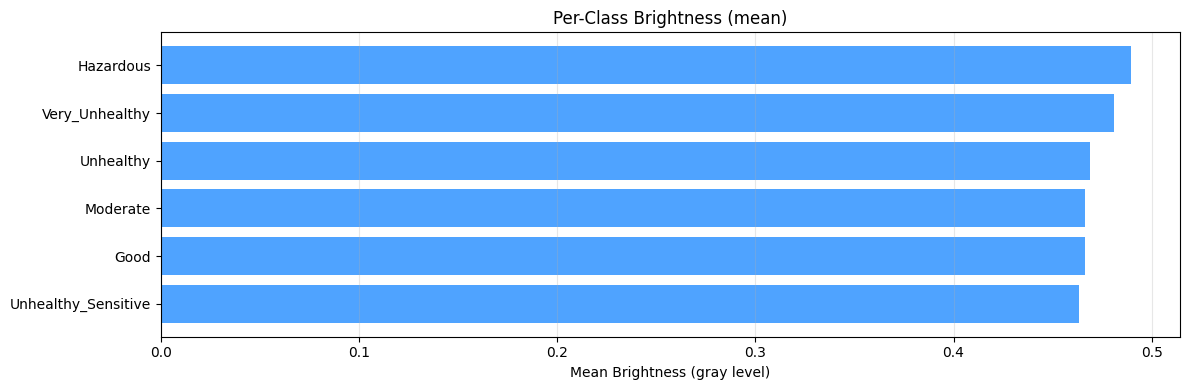

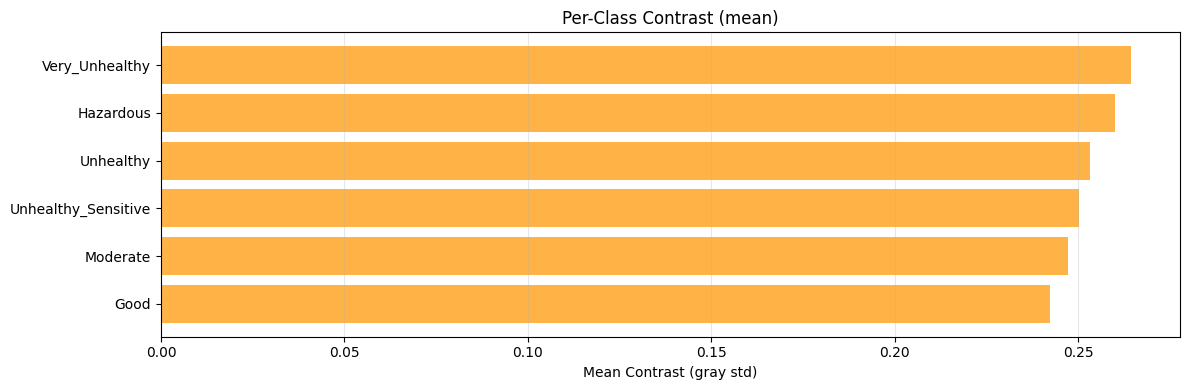

In [10]:
brightness_mean = (df.groupby("label")["brightness"]
                     .mean()
                     .sort_values(ascending=False))

plt.figure(figsize=(12, max(4, 0.35*len(brightness_mean))))
plt.barh(brightness_mean.index, brightness_mean.values, color="#4fa3ff")
plt.gca().invert_yaxis()
plt.xlabel("Mean Brightness (gray level)")
plt.title("Per-Class Brightness (mean)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

contrast_mean = (df.groupby("label")["contrast"]
                   .mean()
                   .sort_values(ascending=False))

plt.figure(figsize=(12, max(4, 0.35*len(contrast_mean))))
plt.barh(contrast_mean.index, contrast_mean.values, color="#ffb347")
plt.gca().invert_yaxis()
plt.xlabel("Mean Contrast (gray std)")
plt.title("Per-Class Contrast (mean)")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

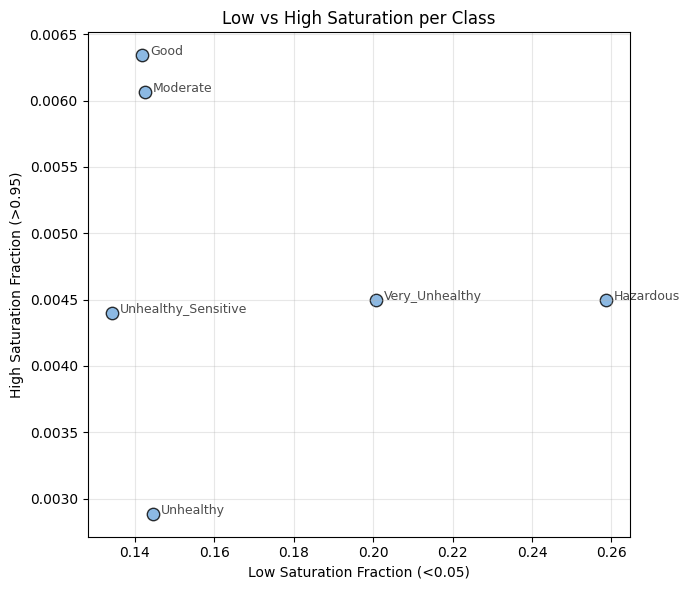

In [11]:
import matplotlib.pyplot as plt

sat_stats = (df.groupby("label")[["sat_low_pct", "sat_high_pct"]]
               .mean()
               .sort_values("sat_low_pct", ascending=False))

plt.figure(figsize=(7,6))
plt.scatter(sat_stats["sat_low_pct"], sat_stats["sat_high_pct"],
            s=80, c="#6fa8dc", edgecolors="black", alpha=0.8)

for lbl, (x, y) in sat_stats.iterrows():
    plt.text(x + 0.002, y, lbl, fontsize=9, alpha=0.7)

plt.xlabel("Low Saturation Fraction (<0.05)")
plt.ylabel("High Saturation Fraction (>0.95)")
plt.title("Low vs High Saturation per Class")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



Resolution & aspect ratio + resize/pad strategy

              width        height        aspect
count  11103.000000  11103.000000  11103.000000
mean    1023.209493    680.079438      1.537895
std       17.893218     99.679766      0.230971
min      320.000000    240.000000      0.667101
25%     1024.000000    576.000000      1.333333
50%     1024.000000    768.000000      1.333333
75%     1024.000000    768.000000      1.777778
max     1024.000000   1535.000000      2.939655


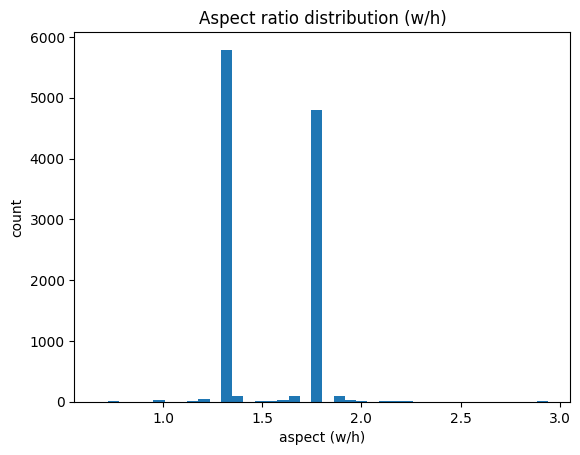

Padding ratio by class (mean):
label
Hazardous              0.291599
Very_Unhealthy         0.312806
Unhealthy_Sensitive    0.333404
Unhealthy              0.338854
Moderate               0.341565
Good                   0.346798
Name: pad_ratio_224, dtype: float64


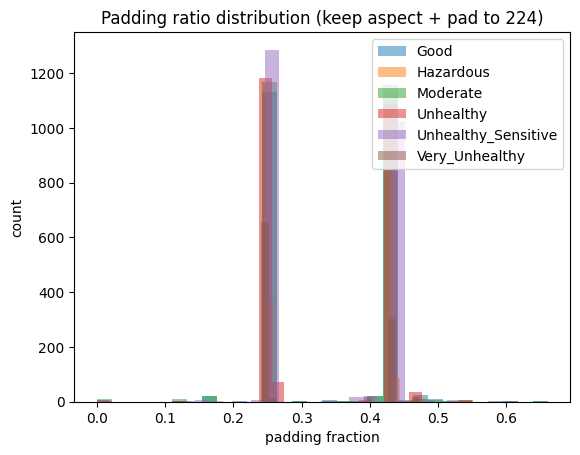

In [12]:
import matplotlib.pyplot as plt

print(df[["width","height","aspect"]].describe())

plt.figure()
plt.hist(df["aspect"], bins=40)
plt.title("Aspect ratio distribution (w/h)")
plt.xlabel("aspect (w/h)")
plt.ylabel("count")
plt.show()

TARGET = 224

def pad_ratio(w, h, target=224):
    scale = target / max(w, h)
    new_w, new_h = int(round(w*scale)), int(round(h*scale))
    pad_w = target - new_w
    pad_h = target - new_h
    padded_pixels = pad_w*target + pad_h*target - pad_w*pad_h
    return padded_pixels / (target*target)

df["pad_ratio_224"] = df.apply(lambda r: pad_ratio(r["width"], r["height"], TARGET), axis=1)

print("Padding ratio by class (mean):")
print(df.groupby("label")["pad_ratio_224"].mean().sort_values())

plt.figure()
for lbl, sub in df.groupby("label"):
    plt.hist(sub["pad_ratio_224"], bins=30, alpha=0.5, label=lbl)
plt.legend()
plt.title("Padding ratio distribution (keep aspect + pad to 224)")
plt.xlabel("padding fraction")
plt.ylabel("count")
plt.show()


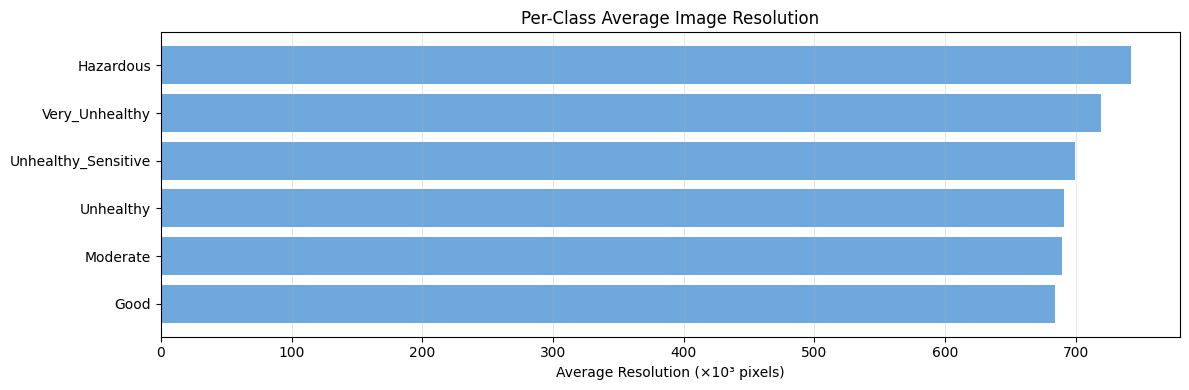

In [13]:
import matplotlib.pyplot as plt

df["resolution"] = df["width"] * df["height"]

res_mean = (df.groupby("label")["resolution"]
              .mean()
              .sort_values(ascending=False) / 1e3)

plt.figure(figsize=(12, max(4, 0.35*len(res_mean))))
plt.barh(res_mean.index, res_mean.values, color="#6fa8dc")
plt.gca().invert_yaxis()
plt.xlabel("Average Resolution (×10³ pixels)")
plt.title("Per-Class Average Image Resolution")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



Sharpness/Noise distributions (per-class)

Laplacian variance by class (mean):
label
Hazardous               889.787888
Unhealthy               999.925401
Very_Unhealthy         1007.536397
Good                   1133.886971
Moderate               1169.038328
Unhealthy_Sensitive    1205.702356
Name: lap_var, dtype: float64

Noise proxy by class (mean):
label
Hazardous              2.471868
Very_Unhealthy         2.575771
Unhealthy              2.694950
Unhealthy_Sensitive    2.901042
Moderate               2.924819
Good                   2.977387
Name: noise_proxy, dtype: float64


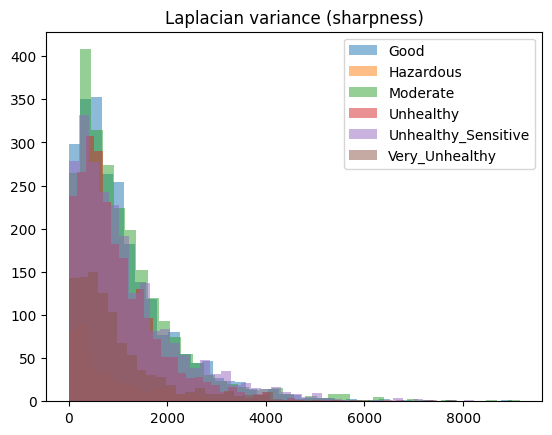

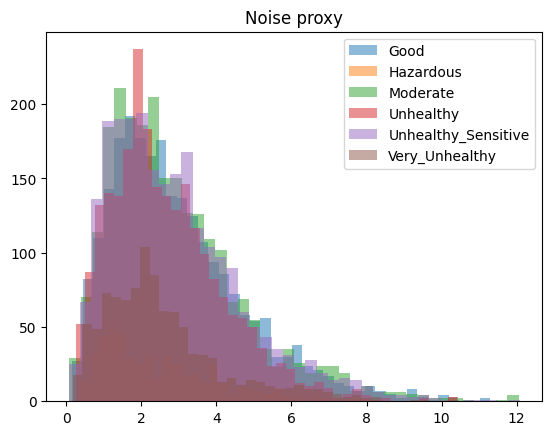

In [25]:
import matplotlib.pyplot as plt

print("Laplacian variance by class (mean):")
print(df.groupby("label")["lap_var"].mean().sort_values())

print("\nNoise proxy by class (mean):")
print(df.groupby("label")["noise_proxy"].mean().sort_values())

plt.figure(); plt.title("Laplacian variance (sharpness)")
for lbl, sub in df.groupby("label"):
    plt.hist(sub["lap_var"], bins=40, alpha=0.5, label=lbl)
plt.legend(); plt.show()

plt.figure(); plt.title("Noise proxy")
for lbl, sub in df.groupby("label"):
    plt.hist(sub["noise_proxy"], bins=40, alpha=0.5, label=lbl)
plt.legend(); plt.show()

White-balance sanity (Gray-world deviation)

Gray-world deviation by class (mean):
label
Hazardous              0.033613
Very_Unhealthy         0.035366
Unhealthy              0.040715
Unhealthy_Sensitive    0.046073
Moderate               0.051227
Good                   0.058542
Name: gray_delta, dtype: float64


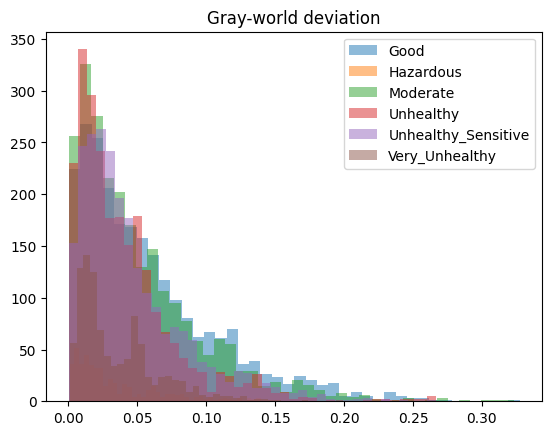

In [15]:
def gray_world_delta(row):
    r, g, b = row["r_mean"], row["g_mean"], row["b_mean"]
    m = (r + g + b) / 3.0
    return float(np.sqrt((r-m)**2 + (g-m)**2 + (b-m)**2))

df["gray_delta"] = df.apply(gray_world_delta, axis=1)

print("Gray-world deviation by class (mean):")
print(df.groupby("label")["gray_delta"].mean().sort_values())

import matplotlib.pyplot as plt
plt.figure()
for lbl, sub in df.groupby("label"):
    plt.hist(sub["gray_delta"], bins=40, alpha=0.5, label=lbl)
plt.legend(); plt.title("Gray-world deviation"); plt.show()

Duplicate detection via perceptual hashing

In [16]:
import os
from collections import defaultdict

import imagehash
from PIL import Image
from tqdm import tqdm

assert "path" in df.columns, "df must contain a 'path' column with image filepaths."

def phash_of_image(path):
    with Image.open(path) as im:
        im = im.convert("RGB")
        return imagehash.phash(im)

hash_to_paths = defaultdict(list)
paths = [p for p in df["path"].astype(str).tolist() if os.path.exists(p)]

for p in tqdm(paths, total=len(paths), desc="Computing pHash"):
    try:
        h = phash_of_image(p)
        hash_to_paths[str(h)].append(p)
    except Exception:
        pass

exact_dupe_groups = [v for v in hash_to_paths.values() if len(v) > 1]
print(f"Exact pHash duplicate groups: {len(exact_dupe_groups)}")

if exact_dupe_groups:
    print("Sample group (first 5 paths):", exact_dupe_groups[0][:5])
else:
    print("No exact-duplicate groups found.")

Computing pHash: 100%|██████████| 11103/11103 [02:11<00:00, 84.14it/s]

Exact pHash duplicate groups: 29
Sample group (first 5 paths): ['/kaggle/working/dataset/Good/3172611009722014.jpg', '/kaggle/working/dataset/Moderate/3172611009722014.jpg']


Class balance table & per-class stats

,n,w_mean,h_mean,aspect_mean,bright_mean,contrast_mean,sat_low,sat_high,sharp_mean,noise_mean,gray_delta
label,,,,,,,,,,,
Good,2408,1023.357973,668.573920,1.566185,0.466436,0.242291,0.141787,0.006342,1133.886971,2.977387,0.058542
Moderate,2407,1023.033236,674.069381,1.552525,0.466541,0.247214,0.142665,0.006062,1169.038328,2.924819,0.051227
Unhealthy,2407,1022.392605,675.815538,1.545625,0.468839,0.253356,0.144711,0.002886,999.925401,2.694950,0.040715
Unhealthy_Sensitive,2393,1023.969912,682.943585,1.531796,0.463135,0.250208,0.134333,0.004403,1205.702356,2.901042,0.046073
Very_Unhealthy,1007,1023.043694,703.686197,1.481135,0.480812,0.264573,0.200856,0.004499,1007.536397,2.575771,0.035366
Hazardous,481,1024.000000,725.419958,1.433543,0.489799,0.260050,0.258590,0.004495,889.787888,2.471868,0.033613


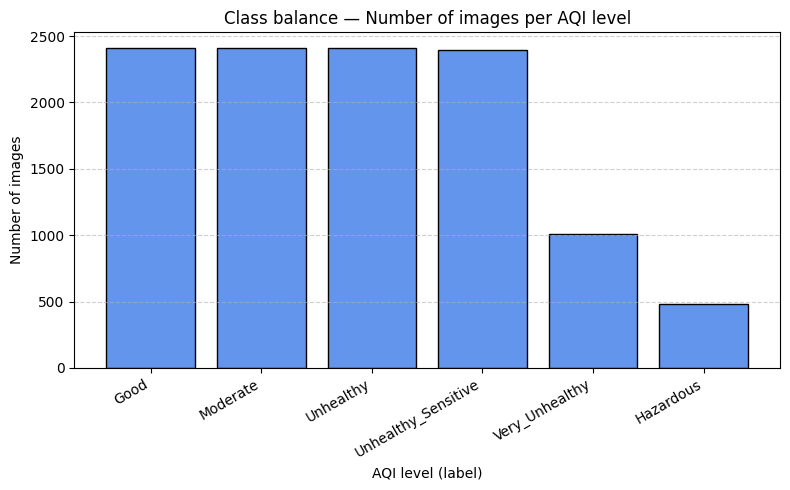

In [20]:
import matplotlib.pyplot as plt

summary = (
    df.groupby("label")
      .agg(
          n=("path","count"),
          w_mean=("width","mean"),
          h_mean=("height","mean"),
          aspect_mean=("aspect","mean"),
          bright_mean=("brightness","mean"),
          contrast_mean=("contrast","mean"),
          sat_low=("sat_low_pct","mean"),
          sat_high=("sat_high_pct","mean"),
          sharp_mean=("lap_var","mean"),
          noise_mean=("noise_proxy","mean"),
          gray_delta=("gray_delta","mean")
      )
      .sort_values("n", ascending=False)
)

display(summary)

plt.figure(figsize=(8,5))
plt.bar(summary.index, summary["n"], color="cornflowerblue", edgecolor="black")
plt.title("Class balance — Number of images per AQI level")
plt.xlabel("AQI level (label)")
plt.ylabel("Number of images")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Leakage safeguards: Grouped stratified splitting

In [21]:
from sklearn.model_selection import GroupKFold
from pathlib import Path

cand_groups = ["station_id", "image_id", "captured_at", "downloaded_at"]
group_key = None
for k in cand_groups:
    if k in df.columns:
        group_key = k
        break

if group_key is None:
    df["group_key"] = df["path"].apply(lambda p: Path(p).stem.split("_")[0])
    group_key = "group_key"

print("Using group key:", group_key)

label_to_id = {l:i for i,l in enumerate(sorted(df["label"].unique()))}
y = df["label"].map(label_to_id).values
groups = df[group_key].astype(str).values

gkf = GroupKFold(n_splits=5)
folds = []
for fold, (tr, va) in enumerate(gkf.split(df, y, groups)):
    folds.append((tr, va))
    print(f"Fold {fold}: train={len(tr)}, val={len(va)}")

tr_idx, va_idx = folds[0]
df_train_split = df.iloc[tr_idx].copy()
df_val_split   = df.iloc[va_idx].copy()

overlap = set(df_train_split[group_key]).intersection(set(df_val_split[group_key]))
print("Group overlap between train/val:", len(overlap))
print("Train class counts:\n", df_train_split["label"].value_counts())
print("Val   class counts:\n", df_val_split["label"].value_counts())

Using group key: group_key
Fold 0: train=8882, val=2221
Fold 1: train=8882, val=2221
Fold 2: train=8882, val=2221
Fold 3: train=8883, val=2220
Fold 4: train=8883, val=2220
Group overlap between train/val: 0
Train class counts:
 label
Unhealthy              1941
Moderate               1923
Good                   1910
Unhealthy_Sensitive    1886
Very_Unhealthy          819
Hazardous               403
Name: count, dtype: int64
Val   class counts:
 label
Unhealthy_Sensitive    507
Good                   498
Moderate               484
Unhealthy              466
Very_Unhealthy         188
Hazardous               78
Name: count, dtype: int64


Small augmentation probe (safety check)

In [22]:
from PIL import ImageEnhance, ImageFilter
import random

SAMPLE_N = 200
sample_paths = df["path"].sample(min(SAMPLE_N, len(df)), random_state=42).tolist()

def aug_pipeline(im):
    if random.random() < 0.5:
        im = im.transpose(Image.FLIP_LEFT_RIGHT)
    W, H = im.size
    scale = random.uniform(0.88, 1.0)
    w2, h2 = int(W * scale), int(H * scale)
    x = random.randint(0, W - w2)
    y = random.randint(0, H - h2)
    im = im.crop((x, y, x + w2, y + h2)).resize((W, H), Image.BICUBIC)
    im = ImageEnhance.Brightness(im).enhance(random.uniform(0.85, 1.15))
    im = ImageEnhance.Contrast(im).enhance(random.uniform(0.85, 1.15))
    im = ImageEnhance.Color(im).enhance(random.uniform(0.85, 1.15))
    if random.random() < 0.1:
        im = im.filter(ImageFilter.GaussianBlur(radius=1.0))
    return im

def metrics_for_paths(paths):
    res = []
    for p in paths:
        arr = load_rgb(p)
        s = rgb_hsv_stats(arr)
        res.append([s["brightness"], s["contrast"], s["s_mean"], s["sat_high_pct"]])
    return np.array(res)

base_metrics = metrics_for_paths(sample_paths)

aug_metrics = []
for p in sample_paths:
    with Image.open(p) as im:
        im = im.convert("RGB")
        im2 = aug_pipeline(im)
        arr = np.array(im2)
    s = rgb_hsv_stats(arr)
    aug_metrics.append([s["brightness"], s["contrast"], s["s_mean"], s["sat_high_pct"]])
aug_metrics = np.array(aug_metrics)

delta = aug_metrics - base_metrics
delta_df = pd.DataFrame(delta, columns=["Δbrightness", "Δcontrast", "ΔS_mean", "Δsat_high_pct"])
print("Augmentation deltas (mean ± std):")
print(delta_df.agg(["mean", "std"]))


Augmentation deltas (mean ± std):
      Δbrightness  Δcontrast   ΔS_mean  Δsat_high_pct
mean    -0.003979  -0.007838 -0.002137       0.003445
std      0.042942   0.027549  0.037868       0.018692


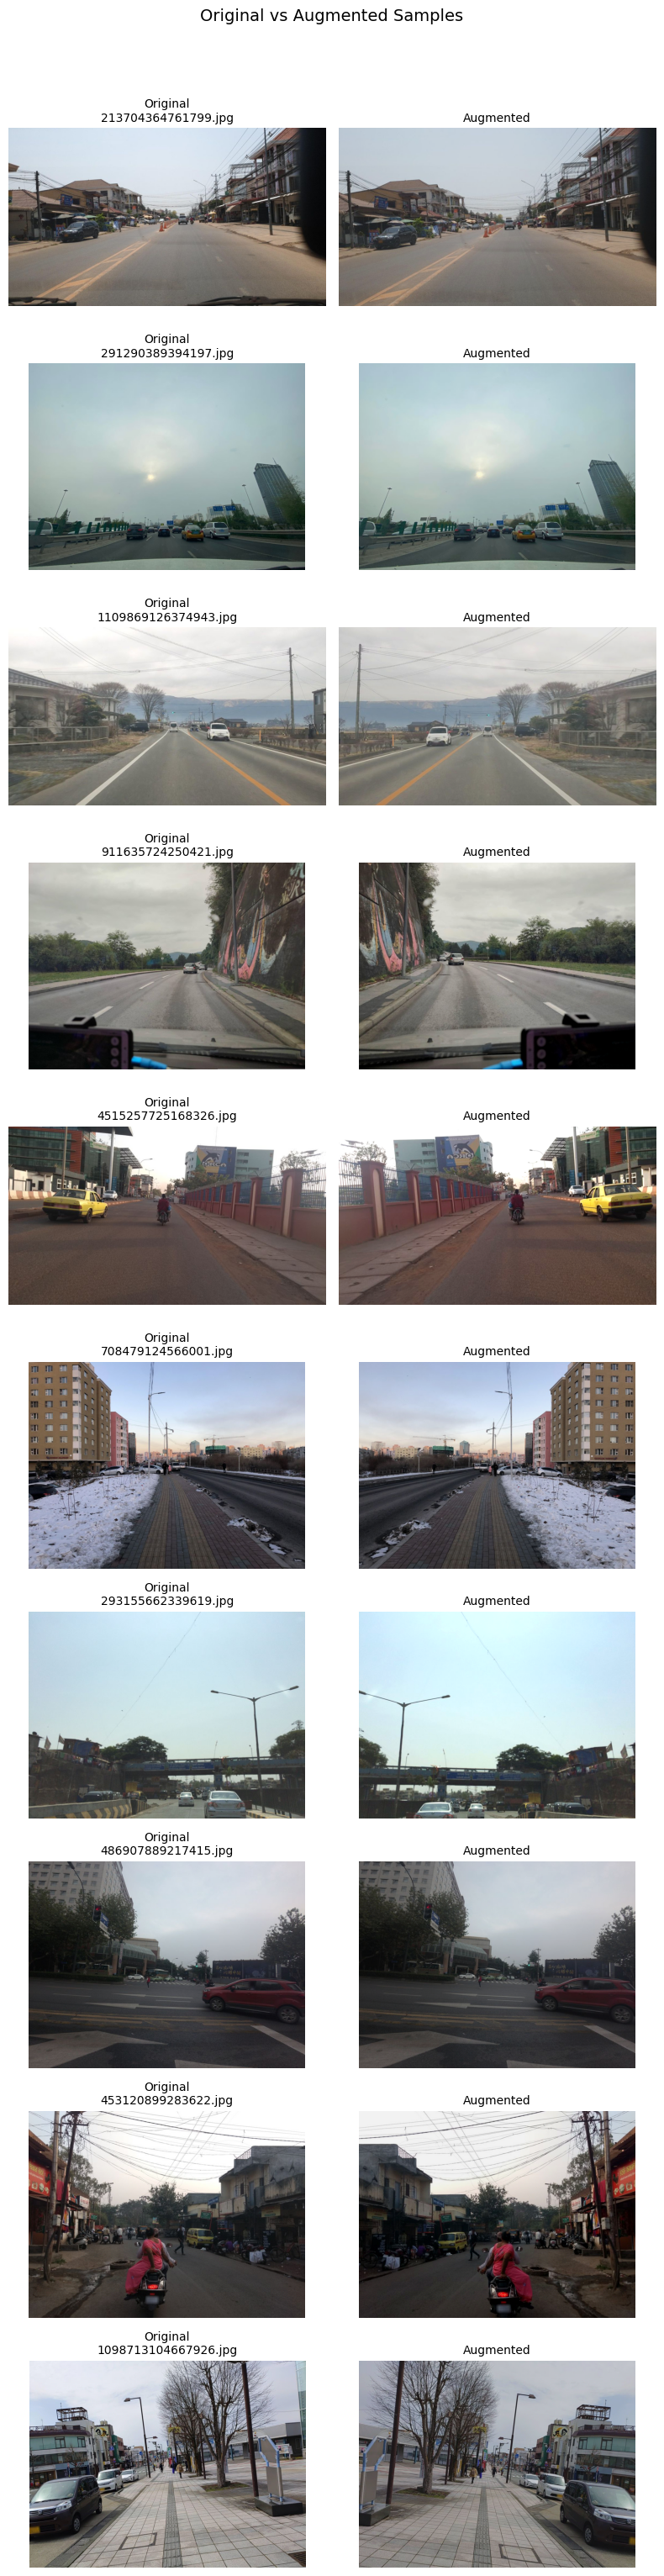

In [23]:

import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

N_SHOW = 10  
fig, axes = plt.subplots(N_SHOW, 2, figsize=(8, 3 * N_SHOW))

for i in range(N_SHOW):
    p = sample_paths[i]
    with Image.open(p) as im:
        im = im.convert("RGB")
        aug_im = aug_pipeline(im.copy())

    axes[i, 0].imshow(im)
    axes[i, 0].set_title(f"Original\n{Path(p).name}", fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(aug_im)
    axes[i, 1].set_title("Augmented", fontsize=10)
    axes[i, 1].axis("off")

plt.suptitle("Original vs Augmented Samples", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
